# 📊 TCC — Análise de Sentimento no Mercado Financeiro Brasileiro
## FASE 2 — Modelagem de Sentimento com FinBERT-PT-BR

**⚠️ ANTES DE RODAR:** Ative a GPU em *Ambiente de execução → Alterar tipo → GPU T4*

**Objetivos desta fase:**
- ✅ Carregar o modelo FinBERT ajustado para português
- ✅ Classificar os textos do dataset em Positivo / Neutro / Negativo
- ✅ Avaliar o modelo com F1-score, Precisão, Revocação e Acurácia
- ✅ Calcular o Kappa de Cohen (concordância com anotação humana)
- ✅ Comparar FinBERT com baseline Naive Bayes (TF-IDF)
- ✅ Calcular IS(d) — Índice diário de sentimento
- ✅ Simular classificação de headlines do mercado brasileiro

---
## 📦 BLOCO 1 — Instalação e Importações

In [18]:
# ── Monta Google Drive e configura pasta do TCC ──
from google.colab import drive
drive.mount('/content/drive')

import os

# Pasta permanente no seu Drive
PASTA_DRIVE = '/content/drive/MyDrive/TCC_dados'
os.makedirs(PASTA_DRIVE, exist_ok=True)

# Cria atalho local 'dados_tcc' apontando para o Drive
if os.path.islink('dados_tcc'):
    os.unlink('dados_tcc')
if not os.path.exists('dados_tcc'):
    os.symlink(PASTA_DRIVE, 'dados_tcc')

print(f'✅ Drive montado! Pasta: {PASTA_DRIVE}')
print(f'✅ Atalho local "dados_tcc" → {PASTA_DRIVE}')

Mounted at /content/drive
✅ Drive montado! Pasta: /content/drive/MyDrive/TCC_dados
✅ Atalho local "dados_tcc" → /content/drive/MyDrive/TCC_dados


In [19]:
!pip install -q transformers torch datasets scikit-learn pandas numpy matplotlib seaborn
print('✅ Dependências instaladas!')

✅ Dependências instaladas!


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score, accuracy_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from datasets import load_dataset

warnings.filterwarnings('ignore')
os.makedirs('dados_tcc', exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

# CORREÇÃO: usar string ('cuda:0' / 'cpu') em vez de inteiro
device_str = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'✅ Dispositivo: {device_name}')
if device_str == 'cpu':
    print('  ⚠️ GPU não detectada. Ative em: Ambiente de execução → Alterar tipo → GPU T4')
    print('  → O código roda em CPU mas será mais lento (~3x)')

✅ Dispositivo: Tesla T4


---
## 📚 BLOCO 2 — Carrega Dataset da Fase 1

In [21]:
CSV_PATH = 'dados_tcc/dataset_sentimento_ptbr.csv'

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f'✅ Dataset carregado do CSV da Fase 1: {len(df):,} registros')
else:
    print('⚠️ CSV da Fase 1 não encontrado. Baixando novamente do HuggingFace...')
    from datasets import load_dataset
    dataset = load_dataset('lucas-leme/Sentiments-FinBERT-PT-BR')
    split = 'train' if 'train' in dataset else list(dataset.keys())[0]
    df_raw = dataset[split].to_pandas()

    col_texto = next((c for c in df_raw.columns if c in ['sentence', 'text', 'texto']), df_raw.columns[0])
    col_label = next((c for c in df_raw.columns if c in ['label', 'sentiment', 'sentimento']), df_raw.columns[-1])

    df = pd.DataFrame()
    df['texto'] = df_raw[col_texto].astype(str)
    # CORREÇÃO: dataset usa strings diretamente como label (não inteiros)
    df['sentimento'] = df_raw[col_label].astype(str)
    print(f'✅ Dataset baixado: {len(df):,} registros')

# Garante coluna 'sentimento' existe
if 'sentimento' not in df.columns and 'label_num' in df.columns:
    mapa_num_str = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo', 3: 'Não se aplica'}
    df['sentimento'] = df['label_num'].map(mapa_num_str)

# CORREÇÃO: remove 'Não se aplica' com aviso explícito
n_total = len(df)
df = df[df['sentimento'].isin(['Negativo', 'Neutro', 'Positivo'])].copy()
n_removidos = n_total - len(df)
if n_removidos > 0:
    print(f'  ℹ️ {n_removidos} registros "Não se aplica" removidos')

# Garante label numérico 0/1/2
mapa_inv = {'Negativo': 0, 'Neutro': 1, 'Positivo': 2}
df['label_num'] = df['sentimento'].map(mapa_inv)
df = df.dropna(subset=['texto', 'sentimento', 'label_num']).copy()
df['label_num'] = df['label_num'].astype(int)

print(f'\nDistribuição final:')
print(df['sentimento'].value_counts())
print(f'\nTotal para modelagem: {len(df):,} registros')

⚠️ CSV da Fase 1 não encontrado. Baixando novamente do HuggingFace...
✅ Dataset baixado: 661 registros
  ℹ️ 158 registros "Não se aplica" removidos

Distribuição final:
sentimento
Negativo    203
Positivo    160
Neutro      140
Name: count, dtype: int64

Total para modelagem: 503 registros


---
## 🤖 BLOCO 3 — Modelo FinBERT-PT-BR (HuggingFace Transformers)

In [22]:
MODEL_NAME = 'lucas-leme/FinBERT-PT-BR'

print(f'⏳ Carregando modelo {MODEL_NAME}...')
print(' (Primeira execução faz download ~400MB — aguarde)\n')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# CORREÇÃO: device como string em vez de inteiro
clf_pipeline = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=device_str,
    truncation=True,
    max_length=512
)

print('✅ Modelo carregado!')
print(f'  Labels do modelo: {model.config.id2label}')

⏳ Carregando modelo lucas-leme/FinBERT-PT-BR...
 (Primeira execução faz download ~400MB — aguarde)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Modelo carregado!
  Labels do modelo: {0: 'POSITIVE', 1: 'NEGATIVE', 2: 'NEUTRAL'}


In [23]:
# CORREÇÃO: normalizar_label() com mapeamento explícito via id2label
_id2label = model.config.id2label
_LABEL_MAP = {}
for idx, raw_label in _id2label.items():
    l = raw_label.upper()
    if 'NEG' in l or l == 'LABEL_0':
        _LABEL_MAP[raw_label] = 'Negativo'
    elif 'NEU' in l or l == 'LABEL_1':
        _LABEL_MAP[raw_label] = 'Neutro'
    elif 'POS' in l or l == 'LABEL_2':
        _LABEL_MAP[raw_label] = 'Positivo'
    else:
        _LABEL_MAP[raw_label] = raw_label

print(f'Mapeamento de labels: {_LABEL_MAP}')

def normalizar_label(label_raw):
    if label_raw in _LABEL_MAP:
        return _LABEL_MAP[label_raw]
    l = label_raw.upper()
    if 'NEG' in l:  return 'Negativo'
    if 'NEU' in l:  return 'Neutro'
    if 'POS' in l:  return 'Positivo'
    return label_raw

Mapeamento de labels: {'POSITIVE': 'Positivo', 'NEGATIVE': 'Negativo', 'NEUTRAL': 'Neutro'}


In [24]:
frases_teste = [
    'Ibovespa sobe 2% após resultado positivo do PIB brasileiro',
    'Banco Central mantém Selic em 10,5% ao ano na reunião do Copom',
    'Bolsa despenca com crise fiscal e medo de recessão global',
    'Petrobras anuncia lucro recorde no terceiro trimestre',
    'Inflação supera expectativas e pressiona ativos de risco no Brasil'
]

print('🧪 Teste de classificação com frases do mercado brasileiro:\n')
resultados = clf_pipeline(frases_teste)

for frase, res in zip(frases_teste, resultados):
    print(f'Texto: "{frase[:70]}"')
    print(f'  → {normalizar_label(res["label"])} (confiança: {res["score"]:.3f})')
    print()

🧪 Teste de classificação com frases do mercado brasileiro:

Texto: "Ibovespa sobe 2% após resultado positivo do PIB brasileiro"
  → Positivo (confiança: 0.818)

Texto: "Banco Central mantém Selic em 10,5% ao ano na reunião do Copom"
  → Neutro (confiança: 0.521)

Texto: "Bolsa despenca com crise fiscal e medo de recessão global"
  → Negativo (confiança: 0.854)

Texto: "Petrobras anuncia lucro recorde no terceiro trimestre"
  → Positivo (confiança: 0.816)

Texto: "Inflação supera expectativas e pressiona ativos de risco no Brasil"
  → Negativo (confiança: 0.826)



---
## 📊 BLOCO 4 — Avaliação do Modelo (F1, Kappa, Matriz de Confusão)

In [25]:
# CORREÇÃO: pd.concat + list comprehension em vez de groupby().apply()
N_AVALIACAO = min(600, len(df))
n_por_classe = N_AVALIACAO // 3

partes = [
    grp.sample(min(n_por_classe, len(grp)), random_state=42)
    for _, grp in df.groupby('sentimento')
]
df_eval = pd.concat(partes, ignore_index=True)

print(f'✅ Amostra de avaliação: {len(df_eval)} textos')
print(f'Distribuição: {df_eval["sentimento"].value_counts().to_dict()}')
print(f'\n⏳ Classificando com FinBERT-PT-BR...')
print('  (pode levar 1-3 minutos dependendo do hardware)')

✅ Amostra de avaliação: 467 textos
Distribuição: {'Negativo': 167, 'Positivo': 160, 'Neutro': 140}

⏳ Classificando com FinBERT-PT-BR...
  (pode levar 1-3 minutos dependendo do hardware)


In [26]:
textos_eval = df_eval['texto'].tolist()
preds_raw = clf_pipeline(textos_eval, batch_size=16, truncation=True, max_length=512)

df_eval = df_eval.copy()
df_eval['pred_sentimento'] = [normalizar_label(r['label']) for r in preds_raw]
df_eval['pred_score'] = [r['score'] for r in preds_raw]
df_eval['pred_num'] = df_eval['pred_sentimento'].map(mapa_inv)

print(f'✅ Classificação concluída!')
print(f'Primeiras predições:')
df_eval[['texto', 'sentimento', 'pred_sentimento', 'pred_score']].head(5)

✅ Classificação concluída!
Primeiras predições:


,texto,sentimento,pred_sentimento,pred_score
0,O Banco Central anunciou nesta terça-feira que...,Negativo,Negativo,0.852944
1,Entre os ativos de maior peso sobre o Ibovespa...,Negativo,Negativo,0.845366
2,"Além de São Paulo, houve protestos em Pernambu...",Negativo,Negativo,0.841279
3,A agência de notícia iraniana Fars disse que a...,Negativo,Negativo,0.850567
4,"Análise técnica da Itaú Corretora, assinada po...",Negativo,Negativo,0.849369


In [27]:
y_true = df_eval['label_num'].values
y_pred = df_eval['pred_num'].values
classes = ['Negativo', 'Neutro', 'Positivo']

acc      = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_pond  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
kappa    = cohen_kappa_score(y_true, y_pred)

print('=' * 55)
print(' MÉTRICAS DE AVALIAÇÃO — FinBERT-PT-BR')
print('=' * 55)
print(f'  Acurácia:            {acc:.4f} ({acc*100:.1f}%)')
print(f'  F1-Score Macro:      {f1_macro:.4f}')
print(f'  F1-Score Ponderado:  {f1_pond:.4f}')
print(f'  Kappa de Cohen:      {kappa:.4f}')
print()

if kappa >= 0.81:   interp = 'Quase perfeito'
elif kappa >= 0.61: interp = 'Substancial'
elif kappa >= 0.41: interp = 'Moderado'
elif kappa >= 0.21: interp = 'Razoável'
else:               interp = 'Leve'
print(f'  Interpretação Kappa: {interp} (Landis & Koch, 1977)')
print('=' * 55)
print()
print('Relatório detalhado por classe:')
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

 MÉTRICAS DE AVALIAÇÃO — FinBERT-PT-BR
  Acurácia:            0.9400 (94.0%)
  F1-Score Macro:      0.9382
  F1-Score Ponderado:  0.9398
  Kappa de Cohen:      0.9097

  Interpretação Kappa: Quase perfeito (Landis & Koch, 1977)

Relatório detalhado por classe:
              precision    recall  f1-score   support

    Negativo       0.95      0.97      0.96       167
      Neutro       0.93      0.89      0.91       140
    Positivo       0.94      0.95      0.94       160

    accuracy                           0.94       467
   macro avg       0.94      0.94      0.94       467
weighted avg       0.94      0.94      0.94       467



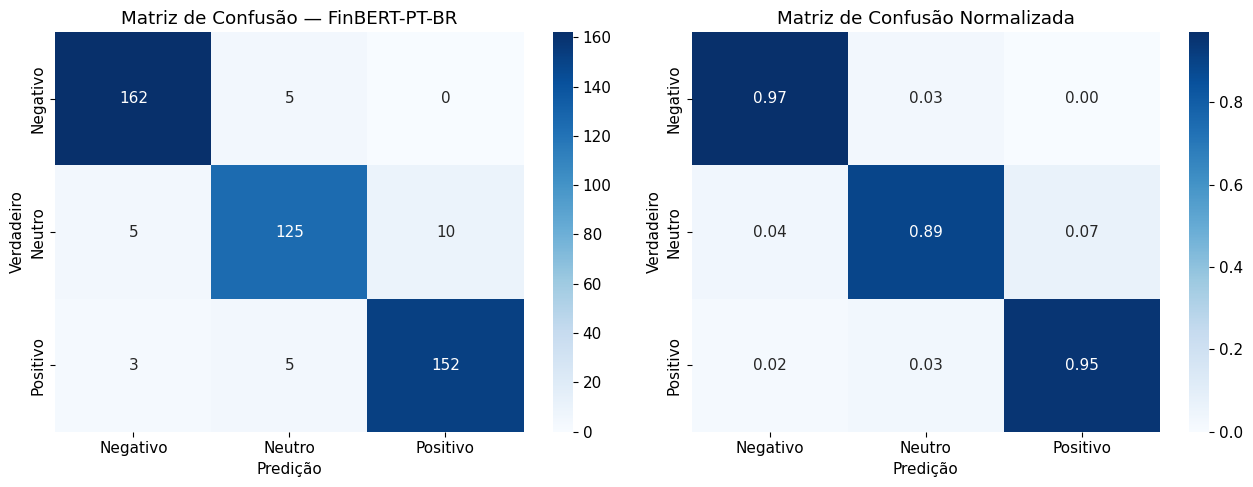

✅ Figura salva: dados_tcc/fig5_matriz_confusao.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_title('Matriz de Confusão — FinBERT-PT-BR')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_xlabel('Predição')
axes[1].set_ylabel('Verdadeiro')
axes[1].set_title('Matriz de Confusão Normalizada')

plt.tight_layout()
plt.savefig('dados_tcc/fig5_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados_tcc/fig5_matriz_confusao.png')

---
## 🆚 BLOCO 5 — Comparação com Baselines (Naive Bayes e Regressão Logística)

In [29]:
X = df['texto'].values
y = df['label_num'].values

baselines = {
    'Naive Bayes (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000, sublinear_tf=True)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'Regressão Logística (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ])
}

resultados_baseline = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, pipe in baselines.items():
    print(f'⏳ Avaliando {nome}...')
    # CORREÇÃO: n_jobs=1 em vez de n_jobs=-1 (evita deadlock no Colab)
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=1)
    resultados_baseline[nome] = scores
    print(f'  F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}')

print(f'\n✅ Baselines avaliados!')

⏳ Avaliando Naive Bayes (TF-IDF)...
  F1-Macro: 0.4910 ± 0.0646
⏳ Avaliando Regressão Logística (TF-IDF)...
  F1-Macro: 0.3882 ± 0.0263

✅ Baselines avaliados!


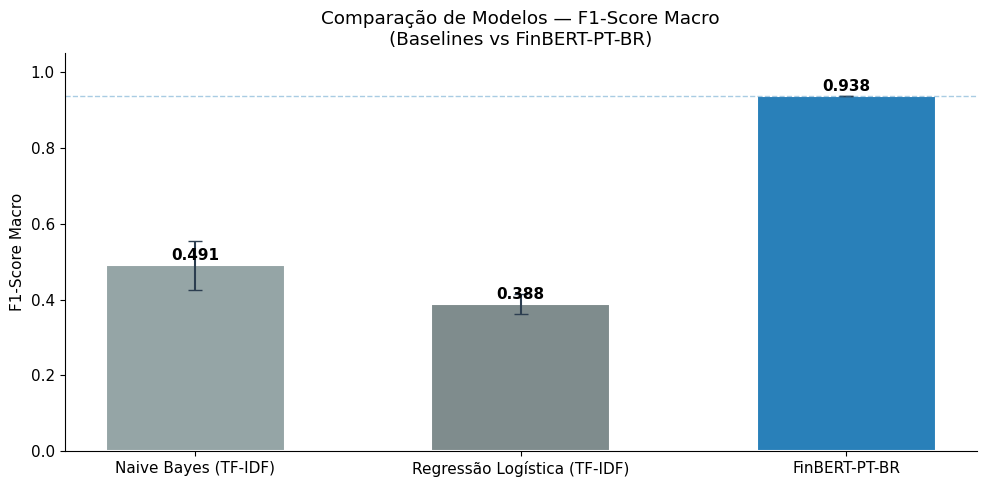

✅ Figura salva: dados_tcc/fig6_comparacao_modelos.png


In [30]:
modelos   = list(resultados_baseline.keys()) + ['FinBERT-PT-BR']
f1_means  = [resultados_baseline[m].mean() for m in list(resultados_baseline.keys())] + [f1_macro]
f1_stds   = [resultados_baseline[m].std()  for m in list(resultados_baseline.keys())] + [0.0]
cores_bars = ['#95a5a6', '#7f8c8d', '#2980b9']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(modelos, f1_means, color=cores_bars, edgecolor='white', linewidth=1.5, width=0.55)
ax.errorbar(range(len(modelos)), f1_means, yerr=f1_stds,
            fmt='none', color='#2c3e50', capsize=5, linewidth=1.5)

for bar, val in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-Score Macro')
ax.set_title('Comparação de Modelos — F1-Score Macro\n(Baselines vs FinBERT-PT-BR)')
ax.axhline(f1_macro, color='#2980b9', linestyle='--', linewidth=1, alpha=0.4)

plt.tight_layout()
plt.savefig('dados_tcc/fig6_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados_tcc/fig6_comparacao_modelos.png')

---
## 📰 BLOCO 6 — Simulação: Headlines Reais do Mercado Brasileiro

In [31]:
headlines_simuladas = [
    {'data': '2020-03-23', 'titulo': 'Ibovespa atinge mínima histórica com pandemia; queda supera 40% no ano'},
    {'data': '2020-05-08', 'titulo': 'Brasil registra maior queda do PIB em décadas no primeiro trimestre'},
    {'data': '2020-11-02', 'titulo': 'Ibovespa supera 100 mil pontos pela primeira vez com otimismo sobre vacinas'},
    {'data': '2021-03-15', 'titulo': 'Selic sobe 0,75 ponto pelo Copom em sinal de combate à inflação'},
    {'data': '2021-06-10', 'titulo': 'B3 bate recorde de investidores pessoa física com 4 milhões cadastrados'},
    {'data': '2021-10-20', 'titulo': 'Crise hídrica e fiscal derrubam bolsa; dólar dispara acima de R$ 5,70'},
    {'data': '2022-02-24', 'titulo': 'Guerra na Ucrânia derruba bolsas globais e eleva pressão sobre commodities'},
    {'data': '2022-04-05', 'titulo': 'Petrobras anuncia lucro recorde de R$ 44 bilhões e ações sobem 5%'},
    {'data': '2022-10-30', 'titulo': 'Mercado oscila com incerteza pós-eleitoral; Ibovespa opera sem direção clara'},
    {'data': '2023-01-12', 'titulo': 'Americanas revela rombo de R$ 20 bilhões e ações desabam 80% em um dia'},
    {'data': '2023-06-21', 'titulo': 'Banco Central sinaliza início do ciclo de corte de juros; bolsa avança 2%'},
    {'data': '2023-08-02', 'titulo': 'Ibovespa alcança 122 mil pontos com queda da Selic e fluxo estrangeiro'},
    {'data': '2024-01-15', 'titulo': 'Preocupação fiscal pressiona mercados; real desvaloriza frente ao dólar'},
    {'data': '2024-04-12', 'titulo': 'Temporada de resultados começa positiva; bancos registram lucros acima do esperado'},
    {'data': '2024-09-18', 'titulo': 'Fed corta juros nos EUA; Ibovespa sobe com melhora do apetite por risco global'}
]

df_headlines = pd.DataFrame(headlines_simuladas)
df_headlines['data'] = pd.to_datetime(df_headlines['data'])
print(f'✅ {len(df_headlines)} headlines carregadas para classificação')

✅ 15 headlines carregadas para classificação


In [32]:
preds_hl = clf_pipeline(df_headlines['titulo'].tolist(), truncation=True, max_length=512)

df_headlines['sentimento'] = [normalizar_label(r['label']) for r in preds_hl]
df_headlines['score']      = [r['score'] for r in preds_hl]
df_headlines['polaridade'] = df_headlines['sentimento'].map({'Positivo': 1, 'Neutro': 0, 'Negativo': -1})

print('✅ Headlines classificadas:\n')
for _, row in df_headlines.iterrows():
    emoji = {'Positivo': '🟢', 'Neutro': '🟡', 'Negativo': '🔴'}.get(row['sentimento'], '⚪')
    print(f"{emoji} [{row['data'].date()}] {row['titulo'][:70]}")
    print(f"   → {row['sentimento']} (confiança: {row['score']:.3f})")
    print()

✅ Headlines classificadas:

🔴 [2020-03-23] Ibovespa atinge mínima histórica com pandemia; queda supera 40% no ano
   → Negativo (confiança: 0.607)

🔴 [2020-05-08] Brasil registra maior queda do PIB em décadas no primeiro trimestre
   → Negativo (confiança: 0.839)

🟢 [2020-11-02] Ibovespa supera 100 mil pontos pela primeira vez com otimismo sobre va
   → Positivo (confiança: 0.713)

🔴 [2021-03-15] Selic sobe 0,75 ponto pelo Copom em sinal de combate à inflação
   → Negativo (confiança: 0.642)

🟢 [2021-06-10] B3 bate recorde de investidores pessoa física com 4 milhões cadastrado
   → Positivo (confiança: 0.768)

🔴 [2021-10-20] Crise hídrica e fiscal derrubam bolsa; dólar dispara acima de R$ 5,70
   → Negativo (confiança: 0.848)

🔴 [2022-02-24] Guerra na Ucrânia derruba bolsas globais e eleva pressão sobre commodi
   → Negativo (confiança: 0.847)

🟢 [2022-04-05] Petrobras anuncia lucro recorde de R$ 44 bilhões e ações sobem 5%
   → Positivo (confiança: 0.770)

🔴 [2022-10-30] Mercado oscil

---
## 📐 BLOCO 7 — Cálculo do IS(d): Índice Diário de Sentimento
Implementação da fórmula do cap. 3.5 do TCC:
**IS(d) = Σᵢ wᵢ · pᵢ / Σᵢ wᵢ**

In [33]:
def calcular_IS(df_noticias, col_data='data', col_polaridade='polaridade', col_score='score'):
    """
    Calcula IS(d) = Σ(wi * pi) / Σ(wi)
    pi = polaridade (+1, 0, -1) | wi = score de confiança do modelo
    """
    df_calc = df_noticias.copy()
    df_calc['peso']      = df_calc[col_score]
    df_calc['numerador'] = df_calc['peso'] * df_calc[col_polaridade]

    # CORREÇÃO: usa .agg() vetorizado em vez de groupby().apply(lambda)
    agg = df_calc.groupby(col_data).agg(
        soma_num=('numerador', 'sum'),
        soma_peso=('peso', 'sum')
    ).reset_index()

    agg['IS'] = np.where(agg['soma_peso'] > 0, agg['soma_num'] / agg['soma_peso'], 0.0)

    IS_diario = agg[[col_data, 'IS']].copy()
    IS_diario.columns = ['data', 'IS']
    IS_diario['data']    = pd.to_datetime(IS_diario['data'])
    IS_diario['IS_ma7']  = IS_diario['IS'].rolling(7, min_periods=1).mean()
    IS_diario['IS_sinal'] = IS_diario['IS'].apply(
        lambda x: 'Positivo' if x > 0.1 else ('Negativo' if x < -0.1 else 'Neutro')
    )
    return IS_diario

df_IS = calcular_IS(df_headlines)

print('✅ IS(d) calculado!')
print(f'  Mínimo: {df_IS["IS"].min():.4f}')
print(f'  Máximo: {df_IS["IS"].max():.4f}')
print(f'  Média:  {df_IS["IS"].mean():.4f}')
print(f'  Desvio: {df_IS["IS"].std():.4f}')
df_IS

✅ IS(d) calculado!
  Mínimo: -1.0000
  Máximo: 1.0000
  Média:  -0.4667
  Desvio: 0.9155


,data,IS,IS_ma7,IS_sinal
0,2020-03-23,-1.0,-1.000000,Negativo
1,2020-05-08,-1.0,-1.000000,Negativo
2,2020-11-02,1.0,-0.333333,Positivo
3,2021-03-15,-1.0,-0.500000,Negativo
4,2021-06-10,1.0,-0.200000,Positivo
5,2021-10-20,-1.0,-0.333333,Negativo
6,2022-02-24,-1.0,-0.428571,Negativo
7,2022-04-05,1.0,-0.142857,Positivo
8,2022-10-30,-1.0,-0.142857,Negativo
9,2023-01-12,-1.0,-0.428571,Negativo


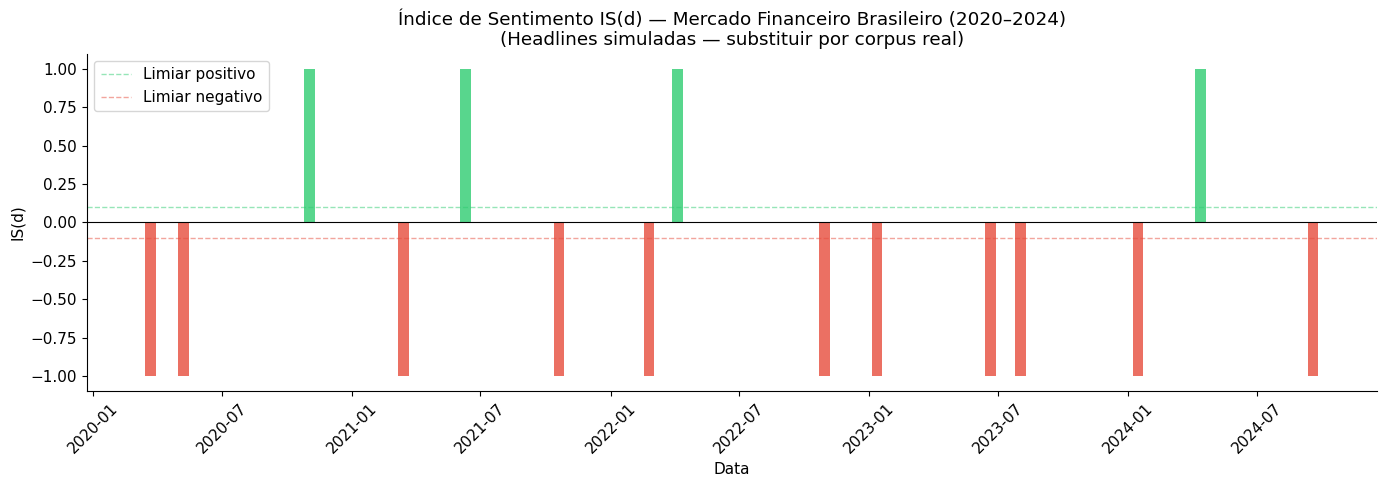

✅ Figura salva: dados_tcc/fig7_IS_diario.png


In [34]:
fig, ax = plt.subplots(figsize=(14, 5))

cores_is = ['#2ecc71' if v > 0.1 else '#e74c3c' if v < -0.1 else '#95a5a6' for v in df_IS['IS']]
ax.bar(df_IS['data'], df_IS['IS'], color=cores_is, width=15, alpha=0.8)
ax.axhline(0,    color='black',   linewidth=0.8)
ax.axhline(0.1,  color='#2ecc71', linewidth=1, linestyle='--', alpha=0.5, label='Limiar positivo')
ax.axhline(-0.1, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.5, label='Limiar negativo')

ax.set_xlabel('Data')
ax.set_ylabel('IS(d)')
ax.set_title('Índice de Sentimento IS(d) — Mercado Financeiro Brasileiro (2020–2024)\n(Headlines simuladas — substituir por corpus real)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('dados_tcc/fig7_IS_diario.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dados_tcc/fig7_IS_diario.png')

In [35]:
df_eval.to_csv('dados_tcc/avaliacao_finbert.csv', index=False)
df_headlines.to_csv('dados_tcc/headlines_classificadas.csv', index=False)
df_IS.to_csv('dados_tcc/IS_diario.csv', index=False)

metricas = pd.DataFrame({
    'Modelo':       ['Naive Bayes (TF-IDF)', 'Regressão Logística (TF-IDF)', 'FinBERT-PT-BR'],
    'F1_Macro':     [resultados_baseline['Naive Bayes (TF-IDF)'].mean(),
                     resultados_baseline['Regressão Logística (TF-IDF)'].mean(), f1_macro],
    'F1_Macro_Std': [resultados_baseline['Naive Bayes (TF-IDF)'].std(),
                     resultados_baseline['Regressão Logística (TF-IDF)'].std(), 0.0],
    'Acuracia':     [None, None, acc],
    'Kappa':        [None, None, kappa]
})
metricas.to_csv('dados_tcc/metricas_modelos.csv', index=False)

print('✅ Arquivos da Fase 2 salvos:')
print('  dados_tcc/avaliacao_finbert.csv')
print('  dados_tcc/headlines_classificadas.csv')
print('  dados_tcc/IS_diario.csv')
print('  dados_tcc/metricas_modelos.csv')
print()
print('🚀 Próximo passo: Fase 3 — Análise Quantitativa (correlação IS × Ibovespa)')

✅ Arquivos da Fase 2 salvos:
  dados_tcc/avaliacao_finbert.csv
  dados_tcc/headlines_classificadas.csv
  dados_tcc/IS_diario.csv
  dados_tcc/metricas_modelos.csv

🚀 Próximo passo: Fase 3 — Análise Quantitativa (correlação IS × Ibovespa)


In [36]:
import shutil, os

# Copia todos os arquivos da sessão para o Drive
src = 'dados_tcc'
dst = '/content/drive/MyDrive/TCC_dados'
for f in os.listdir(src):
    shutil.copy(os.path.join(src, f), dst)
print('✅ Arquivos copiados para o Google Drive!')

✅ Arquivos copiados para o Google Drive!
